# CareTrace — Interpretation Agent

**Objective**: Convert caregiver free-text into structured clinical facts.

**Responsibilities**:
1. Named entity extraction — symptoms, duration, hydration signals, medications
2. Missing-field detection — identify which required fields are still unknown
3. Follow-up question generation — exactly **one** targeted question per turn when fields are missing

**Hard constraints**:
- One question per turn (no information bombardment)
- Must NOT generate clinical advice, diagnosis, or disposition
- Only updates a field when the message provides new information

**Output feeds into**: Knowledge Retrieval Agent (Neo4j KG query) → Safety Logic Agent (PyDatalog)

---
**LLM**: Gemini (swap section at the bottom to use Claude / GPT-4o)

## 0) Install dependencies

In [1]:
#!pip install --quiet -U langgraph langchain-groq pydantic python-dotenv

## 1) Imports

In [2]:
import os
import json
from typing import Optional, Annotated
from typing_extensions import TypedDict

from pydantic import BaseModel, Field

from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langchain_groq import ChatGroq

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver

## 2) LLM configuration

Set your API key, then choose a model. Swap the block at the bottom to use a different provider.

In [3]:
import time
from tenacity import retry, wait_exponential, stop_after_attempt, retry_if_exception_type
from dotenv import load_dotenv

load_dotenv()  # loads GROQ_API_KEY from .env (never committed to git)
GROQ_API_KEY = os.environ.get("GROQ_API_KEY", "")
if not GROQ_API_KEY:
    raise ValueError("Set GROQ_API_KEY in your .env file")

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    groq_api_key=GROQ_API_KEY,
    temperature=0,
)

@retry(
    retry=retry_if_exception_type(Exception),
    wait=wait_exponential(multiplier=1, min=4, max=30),
    stop=stop_after_attempt(5),
    reraise=True,
)
def invoke_with_retry(chain, input):
    return chain.invoke(input)

print("LLM ready:", llm.model_name)

# ── Other Groq model options ────────────────────────────────────────────────
# "llama-3.1-8b-instant"   (fast, lightweight)
# "llama3-70b-8192"
# "mixtral-8x7b-32768"

# Claude (Anthropic)
# from langchain_anthropic import ChatAnthropic
# llm = ChatAnthropic(model="claude-opus-4-6", temperature=0)

# OpenAI
# from langchain_openai import ChatOpenAI
# llm = ChatOpenAI(model="gpt-4o", temperature=0)

LLM ready: llama-3.3-70b-versatile


In [4]:
import requests

def test_groq_key(api_key: str, model: str):
    url = "https://api.groq.com/openai/v1/chat/completions"
    headers = {"Authorization": f"Bearer {api_key}", "Content-Type": "application/json"}
    body = {"model": model, "messages": [{"role": "user", "content": "Say hello in one word."}], "max_tokens": 10}
    r = requests.post(url, json=body, headers=headers, timeout=30)
    if r.status_code == 200:
        text = r.json()["choices"][0]["message"]["content"]
        print(f"\u2705 {model}: works! Response: {text.strip()}")
    elif r.status_code == 429:
        print(f"\u26a0\ufe0f  {model}: rate limited (429)")
    elif r.status_code == 401:
        print(f"\u274c {model}: invalid API key (401)")
    else:
        print(f"\u274c {model}: error {r.status_code} \u2014 {r.json().get('error',{}).get('message','')[:200]}")

# Test — whichever shows ✅ use that one
test_groq_key(GROQ_API_KEY, "llama-3.3-70b-versatile")
test_groq_key(GROQ_API_KEY, "llama-3.1-8b-instant")
test_groq_key(GROQ_API_KEY, "mixtral-8x7b-32768")

✅ llama-3.3-70b-versatile: works! Response: Hello.
✅ llama-3.1-8b-instant: works! Response: Hello.
❌ mixtral-8x7b-32768: error 400 — The model `mixtral-8x7b-32768` has been decommissioned and is no longer supported. Please refer to https://console.groq.com/docs/deprecations for a recommendation on which model to use instead.


## 3) Clinical state

All clinical fields start as `None` (unknown).  
The agent only updates a field when the caregiver message provides new information.

In [5]:
class ClinicalState(TypedDict):
    # ── Conversation ──────────────────────────────────────────────────────────
    messages: Annotated[list, add_messages]  # full conversation history
    turn: int

    # ── Extracted clinical fields (None = unknown) ────────────────────────────
    fever:              Optional[str]    # "yes" | "no"
    #temperature_f:      Optional[float]  # numeric temperature in °F
    #fever_duration_days:Optional[float]
    vomiting:           Optional[str]    # "none" | "once" | "repeated"
    alert:              Optional[str]    # "normal" | "reduced"
    intake:           Optional[str]    # "normal" | "reduced" | "none"
    urination:       Optional[str]    # "normal" | "unknown" | "none"
    #breathing_issues:   Optional[str]    # "yes" | "no"
    #rash:               Optional[str]    # "yes" | "no"
    #neck_pain:          Optional[str]    # "yes" | "no"
    #age_months:         Optional[int]
    #current_medication: Optional[str]
    #medication_last_dose: Optional[str]

    # ── Agent outputs ─────────────────────────────────────────────────────────
    follow_up_question: Optional[str]   # the single question to ask this turn
    is_complete:        bool            # True when all required fields are known


def initial_state() -> ClinicalState:
    """Return a blank state for a new case."""
    return ClinicalState(
        messages=[], turn=0,
        fever=None, temperature_f=None, fever_duration_days=None,
        vomiting=None, alert=None, drinking=None, urination_8h=None,
        breathing_issues=None, rash=None, neck_pain=None,
        age_months=None, current_medication=None, medication_last_dose=None,
        follow_up_question=None, is_complete=False,
    )

print("ClinicalState defined.")

ClinicalState defined.


## 4) Structured extraction schema (Pydantic)

The LLM returns a validated object — not free text.  
`None` means "no new information in this message" (do not overwrite an already-known value).

In [6]:
class ExtractionResult(BaseModel):
    """Structured clinical facts extracted from a single caregiver message."""
    fever:               Optional[str]   = Field(None, description="'yes' or 'no'")
    #temperature_f:       Optional[float] = Field(None, description="Temperature in °F if stated")
    #fever_duration_days: Optional[float] = Field(None, description="Days fever has been present")
    vomiting:            Optional[str]   = Field(None, description="'none', 'once', or 'repeated'")
    alert:               Optional[str]   = Field(None, description="'normal' if child responds normally, 'reduced' if lethargic/hard to wake")
    intake:            Optional[str]   = Field(None, description="'normal', 'reduced', or 'none'")
    urination:        Optional[str]   = Field(None, description="'normal', 'unknown', or 'none'")
    #breathing_issues:    Optional[str]   = Field(None, description="'yes' or 'no'")
    #rash:                Optional[str]   = Field(None, description="'yes' or 'no'")
    #neck_pain:           Optional[str]   = Field(None, description="'yes' or 'no'")
    #age_months:          Optional[int]   = Field(None, description="Child age in months")
    #current_medication:  Optional[str]   = Field(None, description="Name of medication if mentioned")
    #medication_last_dose:Optional[str]   = Field(None, description="When last dose was given")

print("ExtractionResult schema defined.")

ExtractionResult schema defined.


## 5) Extraction prompt

Strict system prompt that enforces the no-advice constraint.

In [7]:
EXTRACTION_SYSTEM_PROMPT = """You are a clinical information extractor for a pediatric triage system.

YOUR ONLY JOB is to extract structured clinical facts from the caregiver's message.

STRICT RULES:
1. Extract ONLY what the caregiver explicitly states or clearly implies.
2. Set a field to null if the message provides NO new information about it.
3. Do NOT infer, guess, or fill in fields that were not mentioned.
4. Do NOT generate clinical advice, diagnosis, treatment, or disposition — ever.
5. Age conversion: if given in years, convert to months (e.g. "6 years" → 72).
6. Temperature conversion: if given in Celsius, convert to Fahrenheit.
7. Vomiting: 'none' = no vomiting, 'once' = one episode, 'repeated' = more than once.
"""

extractor = llm.with_structured_output(ExtractionResult)

print("Extractor ready.")

Extractor ready.


## 6) Required-field priority list

The agent works through this list in order and asks the **first** unknown field each turn.  
Ordering reflects clinical safety priority.

In [8]:
# (field_name, question_to_ask_if_unknown)
REQUIRED_FIELDS = [
    ("alert",             "Is your child awake and responding normally when you talk to them?"),
    #("breathing_issues",  "Is your child having any trouble breathing or breathing fast?"),
    #("temperature_f",     "What is the temperature right now?"),
    ("urination",      "Has your child urinated in the last 8 hours?"),
    ("intake",          "Is your child drinking any fluids?"),
    ("fever",           "Does your child have a fever?"),
    ("vomiting",        "Has your child vomited in the last 24 hours?"),
    #("current_medication","Is your child currently taking any medications?"),
]

def find_missing_required(state: ClinicalState) -> list[str]:
    """Return list of required field names that are still unknown."""
    return [f for f, _ in REQUIRED_FIELDS if state.get(f) is None]

def next_question(state: ClinicalState) -> Optional[str]:
    """Return the single highest-priority question to ask, or None if all known."""
    for field, question in REQUIRED_FIELDS:
        if state.get(field) is None:
            return question
    return None

print("Required fields:", [f for f, _ in REQUIRED_FIELDS])

Required fields: ['alert', 'urination', 'intake', 'fever', 'vomiting']


## 7) Agent node

In [9]:
def interpret_node(state: ClinicalState) -> dict:
    """
    Interpretation Agent node.

    1. Run structured extraction on the latest caregiver message.
    2. Merge new facts into state (never overwrite a known value with None).
    3. Detect the single highest-priority missing required field.
    4. Set is_complete=True when all required fields are known.
    """
    # ── 1. Get latest caregiver message ──────────────────────────────────────
    latest = state["messages"][-1]
    caregiver_text = latest.content if hasattr(latest, "content") else str(latest)

    # Build conversation context for the extractor
    history_text = "\n".join(
        f"{'Caregiver' if isinstance(m, HumanMessage) else 'Agent'}: {m.content}"
        for m in state["messages"][:-1]
    )

    prompt_messages = [
        SystemMessage(content=EXTRACTION_SYSTEM_PROMPT),
    ]
    if history_text:
        prompt_messages.append(
            SystemMessage(content=f"Conversation so far:\n{history_text}")
        )
    prompt_messages.append(HumanMessage(content=f"Latest message: {caregiver_text}"))

    # ── 2. Extract structured fields ─────────────────────────────────────────
    extracted: ExtractionResult = extractor.invoke(prompt_messages)

    # ── 3. Merge: only update state fields that are currently None ────────────
    updates = {}
    for field in ExtractionResult.model_fields:
        new_val = getattr(extracted, field)
        if new_val is not None and state.get(field) is None:
            updates[field] = new_val

    # Build updated state snapshot for missing-field check
    merged = {**state, **updates}

    # ── 4. Detect next question / completeness ────────────────────────────────
    question = next_question(merged)
    updates["follow_up_question"] = question
    updates["is_complete"] = (question is None)
    updates["turn"] = state.get("turn", 0) + 1  # default to 0 on first turn

    # ── 5. Add agent's question to messages so the next turn has context ──────
    if question:
        updates["messages"] = [AIMessage(content=question)]

    return updates


print("interpret_node defined.")

interpret_node defined.


## 8) Build the LangGraph

Simple loop: caregiver message → extract → END (repeat each turn).  
`InMemorySaver` persists state across turns within the same `thread_id`.

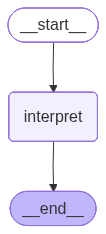

In [10]:
from IPython.display import Image, display

builder = StateGraph(ClinicalState)
builder.add_node("interpret", interpret_node)
builder.add_edge(START, "interpret")
builder.add_edge("interpret", END)

memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))

## 9) Helper — run one turn

In [11]:
def run_turn(caregiver_message: str, thread_id: str = "case-001") -> dict:
    """
    Send one caregiver message and return the updated clinical state.
    Uses thread_id for multi-turn memory.
    """
    config = {"configurable": {"thread_id": thread_id}}
    result = graph.invoke(
        {"messages": [HumanMessage(content=caregiver_message)]},
        config=config,
    )
    return result


def print_state(state: dict):
    """Pretty-print the current clinical state."""
    clinical_fields = [
        "fever", "vomiting","alert", "intake", "urination" 
        #"temperature_f", "fever_duration_days", "breathing_issues",
        #"rash", "neck_pain", "age_months", "current_medication", "medication_last_dose",
    ]
    print(f"\n── Turn {state['turn']} " + "─" * 40)
    print("Clinical fields:")
    for f in clinical_fields:
        val = state.get(f)
        marker = "✓" if val is not None else "?"
        print(f"  [{marker}] {f:<25} {val}")
    print()
    if state["is_complete"]:
        print("  ✅ All required fields known — ready for KG + rules.")
    else:
        print(f"  ❓ Agent asks: '{state['follow_up_question']}'")

print("Helpers ready.")

Helpers ready.


## 10) Test — multi-turn conversation (lecture scenario)

Replays Turns 1–3 from the lecture slides to verify extraction and question generation.

In [12]:
THREAD = "test-scenario-1"

# Turn 1 — initial caregiver message
msg1 = "My 6-year-old has a fever, threw up once, and looks really wiped out. I'm not sure what to do tonight."
print(f"Caregiver: {msg1}")
state1 = run_turn(msg1, THREAD)
print_state(state1)

Caregiver: My 6-year-old has a fever, threw up once, and looks really wiped out. I'm not sure what to do tonight.

── Turn 1 ────────────────────────────────────────
Clinical fields:
  [✓] fever                     yes
  [✓] vomiting                  once
  [✓] alert                     reduced
  [?] intake                    None
  [?] urination                 None

  ❓ Agent asks: 'Has your child urinated in the last 8 hours?'


In [13]:
# Turn 2 — caregiver answers the question
msg2 = "Temp is 101.8. He's tired but answers me. No breathing issues. He's sipping water, not much though. He's been on medication for a recent ear infection."
print(f"Caregiver: {msg2}")
state2 = run_turn(msg2, THREAD)
print_state(state2)

Caregiver: Temp is 101.8. He's tired but answers me. No breathing issues. He's sipping water, not much though. He's been on medication for a recent ear infection.

── Turn 2 ────────────────────────────────────────
Clinical fields:
  [✓] fever                     yes
  [✓] vomiting                  once
  [✓] alert                     reduced
  [✓] intake                    reduced
  [?] urination                 None

  ❓ Agent asks: 'Has your child urinated in the last 8 hours?'


In [14]:
# Turn 3 — caregiver provides more info
msg3 = "He's on amoxicillin. Last dose was earlier tonight. Just vomited once. He peed earlier this evening."
print(f"Caregiver: {msg3}")
state3 = run_turn(msg3, THREAD)
print_state(state3)

Caregiver: He's on amoxicillin. Last dose was earlier tonight. Just vomited once. He peed earlier this evening.

── Turn 3 ────────────────────────────────────────
Clinical fields:
  [✓] fever                     yes
  [✓] vomiting                  once
  [✓] alert                     reduced
  [✓] intake                    reduced
  [✓] urination                 normal

  ✅ All required fields known — ready for KG + rules.


In [15]:
## 11) Interactive conversation loop

import uuid

def run_interactive():
    """
    Chat loop: caregiver types messages until all required fields are known.
    Type 'quit' or 'exit' to stop early.
    Each session gets a fresh thread so state never carries over.
    Returns the final state dict, or None if the session was quit early.
    """
    thread_id = "interactive-" + uuid.uuid4().hex[:6]
    print(f"\n{'='*50}")
    print("=== New CareTrace Session ===")
    print("Describe your child's symptoms. Type 'quit' to exit.\n")

    first_message = input("Caregiver: ").strip()
    if first_message.lower() in ("quit", "exit"):
        return None

    state = run_turn(first_message, thread_id)
    print_state(state)

    while not state["is_complete"]:
        print(f"\nAgent: {state['follow_up_question']}")
        reply = input("Caregiver: ").strip()
        if reply.lower() in ("quit", "exit"):
            print("Session ended early.")
            return None
        state = run_turn(reply, thread_id)
        print_state(state)

    print("\n\u2705 All required fields collected. Ready for knowledge retrieval.")
    return state


# Keep running new sessions until user declines
last_state = None
while True:
    result = run_interactive()
    if result is not None:
        last_state = result
    again = input("\nStart a new session? (y/n): ").strip().lower()
    if again != "y":
        print("Done.")
        break



=== New CareTrace Session ===
Describe your child's symptoms. Type 'quit' to exit.


── Turn 1 ────────────────────────────────────────
Clinical fields:
  [✓] fever                     yes
  [✓] vomiting                  once
  [✓] alert                     reduced
  [?] intake                    None
  [?] urination                 None

  ❓ Agent asks: 'Has your child urinated in the last 8 hours?'

Agent: Has your child urinated in the last 8 hours?

── Turn 2 ────────────────────────────────────────
Clinical fields:
  [✓] fever                     yes
  [✓] vomiting                  once
  [✓] alert                     reduced
  [?] intake                    None
  [✓] urination                 normal

  ❓ Agent asks: 'Is your child drinking any fluids?'

Agent: Is your child drinking any fluids?

── Turn 3 ────────────────────────────────────────
Clinical fields:
  [✓] fever                     yes
  [✓] vomiting                  once
  [✓] alert                     reduced
  [✓]

## 11) Inspect extracted state as a clean dict

This is what gets passed to the **Knowledge Retrieval Agent** and **Safety Logic Agent**.

In [19]:
clinical_fields = [
        "fever", "vomiting","alert", "intake", "urination" 
        #"temperature_f", "fever_duration_days", "breathing_issues",
        #"rash", "neck_pain", "age_months", "current_medication", "medication_last_dose",
    ]

# Uses last_state from run_interactive() — the final completed session
case_facts = {f: last_state.get(f) for f in clinical_fields}
print(json.dumps(case_facts, indent=2))


{
  "fever": "yes",
  "vomiting": "once",
  "alert": "reduced",
  "intake": "some",
  "urination": "normal"
}


## 12) Test — constraint verification

Verify the agent never produces advice or asks more than one question.

In [17]:
# Fresh thread — check single-question constraint
THREAD2 = "test-constraint-check"
msg = "My daughter has a fever and has been vomiting."
result = run_turn(msg, THREAD2)

q = result["follow_up_question"]
print(f"Follow-up question: '{q}'")
assert q is not None, "Should ask a question — required fields still missing"
assert "?" in q, "Should be phrased as a question"
print("✓ Exactly one question generated.")
print("✓ No clinical advice in output (structured fields only).")

Follow-up question: 'Is your child awake and responding normally when you talk to them?'
✓ Exactly one question generated.
✓ No clinical advice in output (structured fields only).


In [18]:
# Complete case — verify is_complete flag
THREAD3 = "test-complete-case"
full_msg = (
    "My 18-month-old has had a fever of 102.5 for one day. "
    "She vomited once. She is alert and responds to me normally. "
    "She is sipping fluids. She urinated about 4 hours ago. "
    "No trouble breathing, no rash, no neck pain. "
    "She is not on any medications."
)
result_full = run_turn(full_msg, THREAD3)
print_state(result_full)
assert result_full["is_complete"], "All required fields provided — should be complete"
print("✓ is_complete = True when all required fields are known.")


── Turn 1 ────────────────────────────────────────
Clinical fields:
  [✓] fever                     yes
  [✓] vomiting                  once
  [✓] alert                     normal
  [✓] intake                    reduced
  [✓] urination                 unknown

  ✅ All required fields known — ready for KG + rules.
✓ is_complete = True when all required fields are known.


## 13) Interface for CareTrace integration

When plugging into the full CareTrace LangGraph, the output of this agent is:
```python
{
    "case_facts": dict,          # clinical fields → passed to KG retrieval
    "is_complete": bool,         # routing: True → KG+rules, False → ask_question
    "follow_up_question": str,   # shown to caregiver if is_complete=False
}
```

Routing in the CareTrace orchestrator:
```python
def route_after_interpret(state):
    if state["is_complete"]:
        return "knowledge_retrieval"   # → KG query → PyDatalog
    else:
        return "ask_caregiver"         # → show follow_up_question → wait for next turn
```